In [1]:
%matplotlib widget

In [2]:
import numpy as np
import pygimli as pg
import empymod as ep
from scipy.constants import mu_0
import matplotlib.pyplot as plt
import sys
sys.path.insert(1, 'src')

from FDEM1D import FDEM1D, FDEM1DModelling, LCModelling
from showStitched import showStitchedModels

In [3]:
# First step: check configuration of FDEM to perform forward
# Second step: check number of layers in FDEM1D Modelling forward class

In [74]:
## Create a test model

pos = 10
nLayers = 3

x =  np.linspace(0,pos,pos, endpoint=False)
sigm_1 = 20/1000
sigm_2 = 100/1000
sigm_3 = 20/1000
#sigm_4 = 100/1000
thk_1 = x/9 + 2 #np.sin(np.pi/2*x/3) + 2
thk_2 = 5 - thk_1 # 1/9*x + 1.5
#thk_3 = np.ones_like(x)

models = np.zeros((pos, nLayers*2-1))
models[:,0] = thk_1
models[:,1] = thk_2
#models[:,2] = thk_3
models[:,2] = sigm_1
models[:,3] = sigm_2
models[:,4] = sigm_3
#models[:,6] = sigm_4

nSoundings = pos

## Create test data

data_t = []

for p in range(pos):
    data_t.append(FDEM1D(models[p,2:], models[p,:2]))

<AxesSubplot:title={'center':'True Model'}>

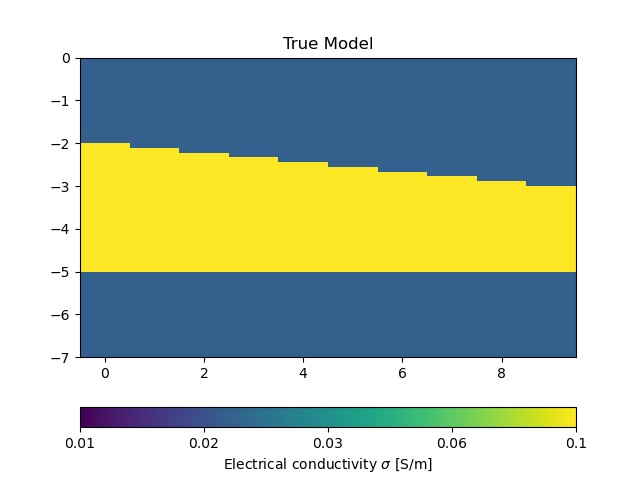

In [76]:
inputs ={'label' : 'Electrical conductivity $\sigma$ [S/m]',
         'cMin': 10/1000,
         'cMax': 100/1000}

showStitchedModels(models, zMax=7, title = 'True Model', **inputs)

# LCI

In [77]:
LC = LCModelling(FDEM1DModelling)

Inversion is normalized


In [78]:
LC.initJacobian(dataVals=data_t, nLay=nLayers)
LC.createJacobian(models)
LC.constraint_matrix(data_t, nLay=nLayers)
LC.normalization(data_t, cWeight_1=0.1, cWeight_2=1, nLay=nLayers)
LC.createWeight(data_t, cWeight_1=0.1, cWeight_2=1, nLay=nLayers)
LC.createConstraints()


Jacobian size: 162 45 180
cWeight for resistivity is dominant
Constraint cWeight: 45 [8.918918918918921, 8.918918918918921, 8.918918918918921, 8.918918918918921, 8.918918918918921, 8.918918918918921, 8.918918918918921, 8.918918918918921, 8.918918918918921, 8.918918918918921, 8.918918918918921, 8.918918918918921, 8.918918918918921, 8.918918918918921, 8.918918918918921, 8.918918918918921, 8.918918918918921, 8.918918918918921, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892, 89.1891891891892]
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f965307a360>


# Inversion

In [79]:
# Initial model
m0 = models.copy()
m0[:,:2] = 2
m0[:,2:] = 50/1000

In [80]:
# Define inversion
#LC.region(1).setConstraintType(1)
#LC.region(2).setConstraintType(1)

inv = pg.Inversion(LC)
data_true = np.array(data_t).ravel()
relativeError = np.ones_like(data_true)*1e-3


28/02/24 - 14:49:44 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper


In [81]:
models_est = inv.run(data_true, relativeError, startModel=m0.ravel(), verbose=False)

28/02/24 - 14:49:45 - pyGIMLi - INFO - Starting model set from given array. [2.   2.   0.05 0.05 0.05 2.   2.   0.05 0.05 0.05 2.   2.   0.05 0.05
 0.05 2.   2.   0.05 0.05 0.05 2.   2.   0.05 0.05 0.05 2.   2.   0.05
 0.05 0.05 2.   2.   0.05 0.05 0.05 2.   2.   0.05 0.05 0.05 2.   2.
 0.05 0.05 0.05 2.   2.   0.05 0.05 0.05]
28/02/24 - 14:49:45 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


<AxesSubplot:title={'center':'Estimated Model LCI'}>

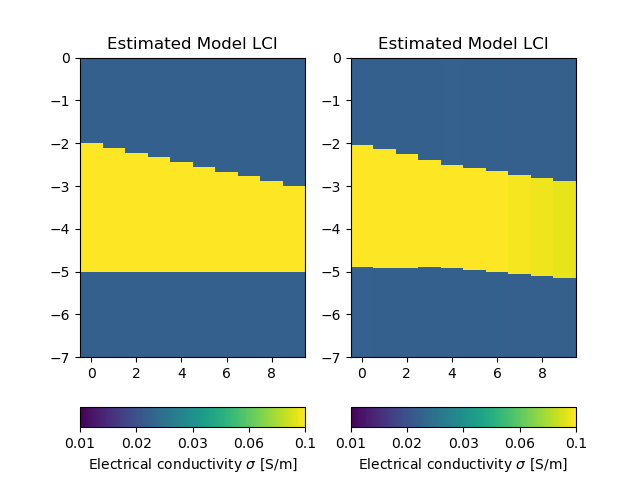

In [82]:
fig, ax = plt.subplots(1,2)

inputs ={'label' : 'Electrical conductivity $\sigma$ [S/m]',
         'cMin': 10/1000,
         'cMax': 100/1000}

showStitchedModels(ax = ax[1], models=np.array(models_est).reshape(np.shape(models)), zMax=7, 
                  title = 'Estimated Model LCI', **inputs)

showStitchedModels(ax = ax[0], models=models, zMax=7, 
                  title = 'Estimated Model LCI', **inputs)
